# 2. 맥북의 중고가를 결정짓는 변수는 무엇일까? 데이터 확인하기

In [1]:
#데이터셋 가져와서 두 변수 간의 상관관계 확인하기
#지금부터 중고 맥북의 가격을 맞춰보는 실습을 해 보려고 합니다!

# 2차원 표 데이터 다룰 때 쓰는 라이브러리 Pandas
import pandas as pd

In [2]:
pwd

'/home/jovyan/work/AIFFEL_study/DA_macbook_bike'

In [ ]:
#다음과 같이 필요한 데이터를 다운로드 받아 주세요. 
#unzip [filename] -d [exdir] 명령어를 통해, 
#~/work/bike_regression 폴더로 압축 풀 위치를 지정합니다.
!wget https://d3s0tskafalll9.cloudfront.net/media/documents/macbook_data.zip

In [ ]:
!unzip macbook_data.zip -d ./

In [3]:
#데이터 확인하기
import os

data_path = os.path.join(os.getenv('HOME'), 'work/AIFFEL_study/DA_macbook_bike/data/macbook.csv')
macbook = pd.read_csv(data_path)
print(macbook.shape)
macbook.head()

(80, 2)


,used_years,price
0,2.65,175
1,3.80,63
2,0.95,273
3,4.50,133
4,4.45,106


In [4]:
#데이터 시각화

In [5]:
#데이터를 가져왔으니, 그래프로 시각화해서 데이터를 조금 더 직관적으로 확인해 보겠습니다.
#그래프를 그리려면, 어떤 라이브러리를 사용할까요?

#matplotlib이라는 라이브러리를 사용합니다. 관습적으로 사용하는 plt 라는 이름으로 가져와 보죠!

import matplotlib.pyplot as plt
# 실행한 브라우저에서 바로 그림을 볼 수 있게 해줌
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # 더 높은 해상도로 출력한다.
print("슝=3")

슝=3


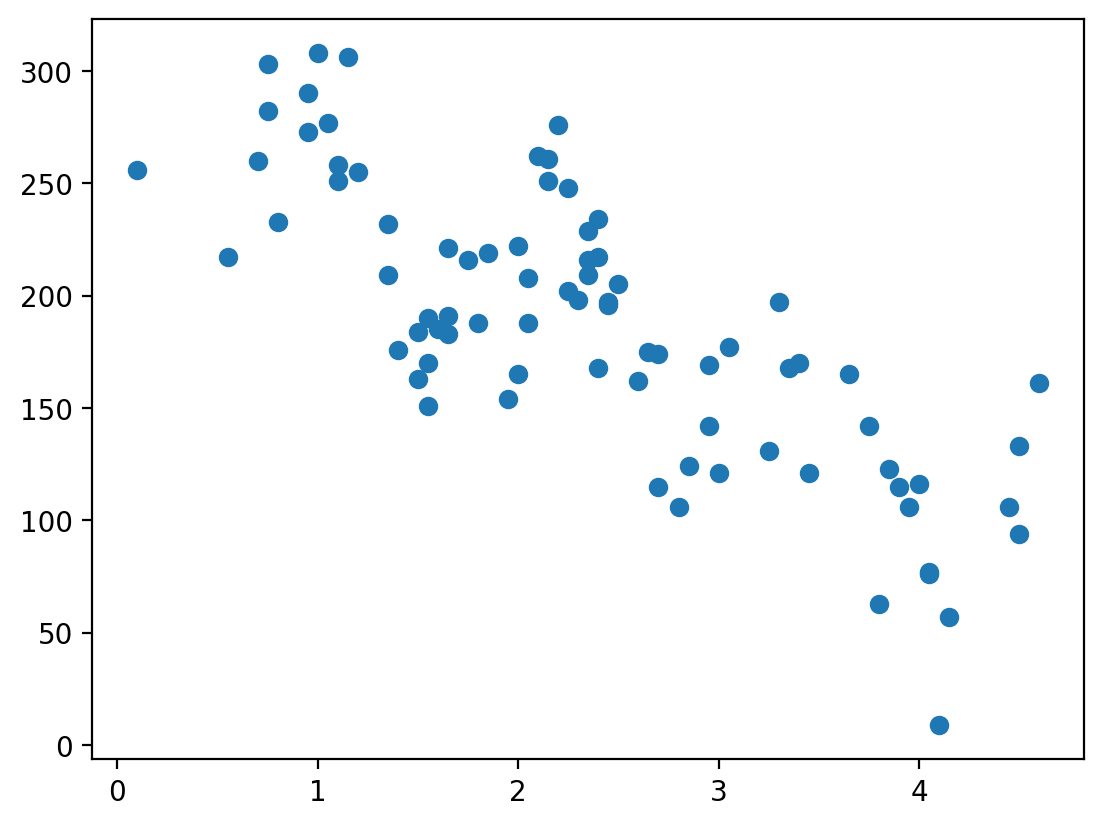

In [6]:
# 그럼 이제 matplotlib으로 2차원 그래프를 그려보겠습니다.
# x 축에는 사용 연수에 해당하는 used_years를, y 축에는 중고가에 해당하는 price를 입력해 보죠.

plt.scatter(macbook['used_years'], macbook['price'])
plt.show()

In [ ]:
#네, 상식적으로도 노트북의 사용연수가 높아지면 중고가는 점점 낮아지겠죠. 두 변수 간에는 분명히 어떤 관계가 존재합니다.

In [8]:
# 상관관계가 있다면, 상관계수 값은 얼마정도인지 확인해 보지 않을 수 없겠죠.

# 통계학 또는 데이터사이언스에서 가장 많이 쓰이는 라이브러리인 numpy 에서는 상관계수를 보여주는 corrcoef() 라는 함수를 제공합니다.

# 상관관계를 확인하고 싶은 두 변수가 있다면 np.corrcoef(x, y) 형태로 넣어주면 됩니다.
    
import numpy as np

# np.corrcoef(x, y)를 사용합니다.
np.corrcoef(macbook['used_years'], macbook['price'])

array([[ 1.        , -0.78972238],
       [-0.78972238,  1.        ]])

# 8-3. '모델'을 만든다는 것, 그 의미 이해하기

In [9]:
#회귀 분석의 시작, 일차함수 모델을 그려보고 그 의미 알아보기

# 그렇다면 우리는 사용연수인 used_years 값을 입력받으면 중고가격이 얼마정도에 해당할지
# 그 값을 잘 예측하는 모델을 만들어볼 수 있을까요?

#입력에 해당하는 x에는 used_years의 정보를, 출력에 해당하는 y에는 price 정보를 담아보겠습니다.
x = macbook["used_years"].values
y = macbook["price"].values

In [10]:
#일차함수 모델

def model(x, w, b):
    y = w * x + b
    return y

In [11]:
model(x=5, w=2, b=1)

11

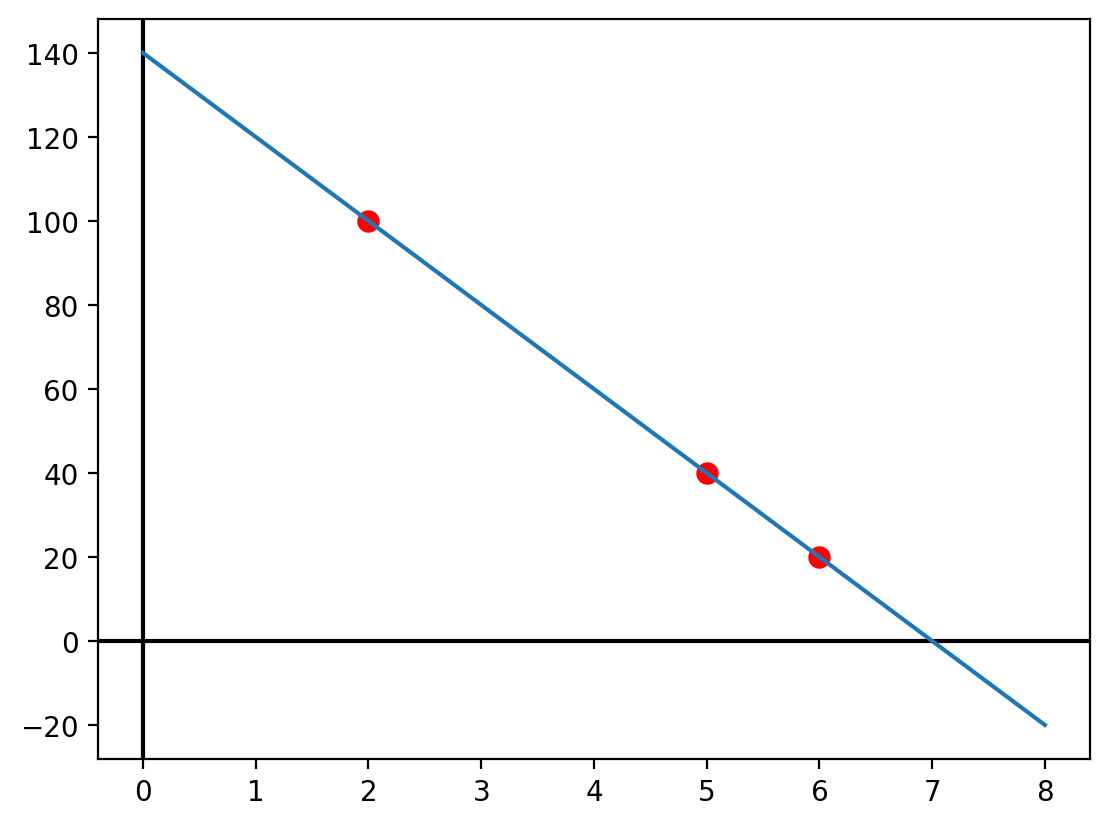

In [12]:
#위에서 구한 함수와 우리에게 있는 (2, 100), (5, 40), (6, 20) 세 가지 점을 그래프로 그려보면 다음과 같습니다.

# x축, y축 그리기
plt.axvline(x=0, c='black')
plt.axhline(y=0, c='black')

# y = wx + b 일차함수 그리기
x = np.linspace(0, 8, 9)
y = model(x, w=-20, b=140) # y = -20x + 140
plt.plot(y)

# 나의 (x, y) 점 찍기
x_data = [2, 5, 6]
y_data = [100, 40, 20]
plt.scatter(x_data, y_data, c='r', s=50)

plt.show()

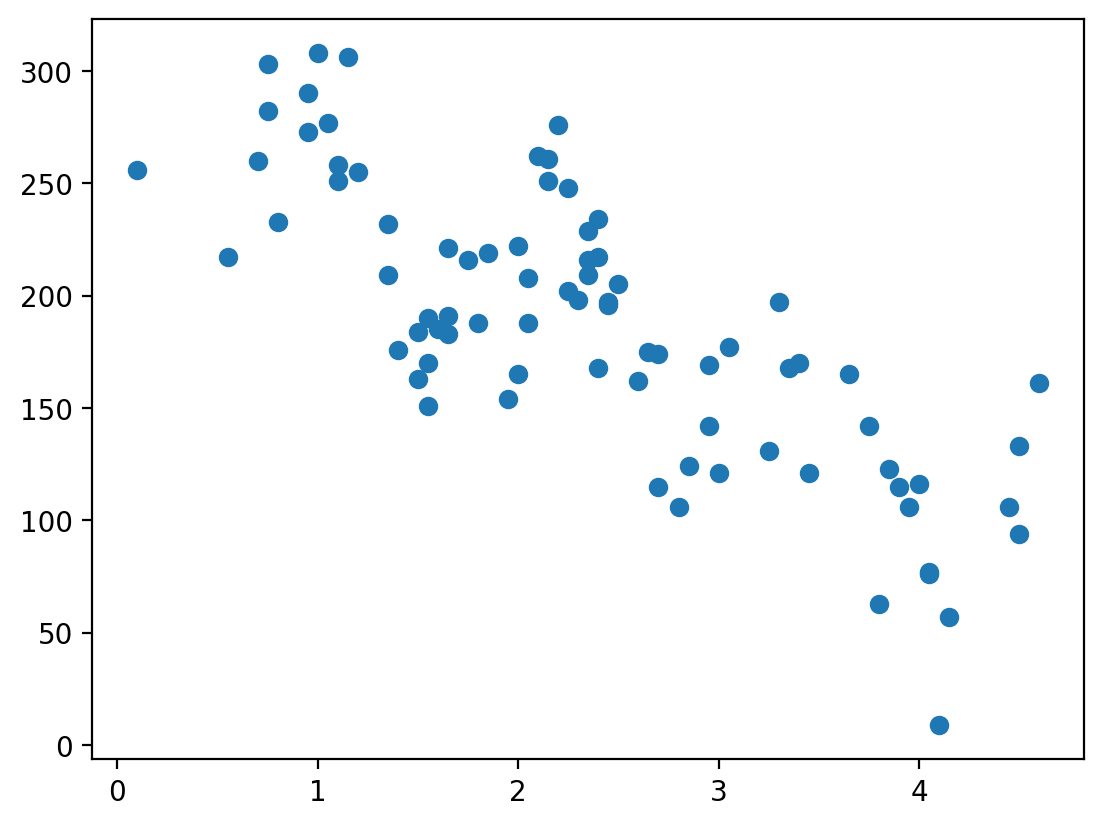

In [13]:
#하지만 사실 우리는 현실에서 이렇게 문제를 풀 수 없습니다 😭
#왜냐구요?! 다시 한 번, 우리의 진짜 데이터를 살펴봅시다.
plt.scatter(macbook['used_years'], macbook['price'])
plt.show()

In [ ]:
#그렇다면 우리는 위 데이터만을 가지고 최적의 파라미터인 w와 b를 어떻게 구할까요?

# 다음 단계부터 방법을 알아보겠습니다.

# 4. 정확한 방정식이 아닌, "최적의 방정식"을 구하는 여정의 시작: 손실함수 정의하기

In [ ]:
#완벽한 정답함수는 존재하지 않더라도, 모델의 출력값과 실제 정답 간의 차이를 계산할 수 있고,
#그 값을 점차 줄여나갈 수 있다면 우리는 점차 최적의 함수에 가까워질 수 있겠죠.

# 따라서 우리는 먼저 1) 모델이 출력하는 값과 실제 정답 간의 차이를 계산하고, 
# 2) 그 차이를 단계적으로 줄여나가는 순서로 모델을 학습시켜 나갈 것입니다.

In [14]:
#예를 들어, 현재 아직 불완전한 모델이 다음과 같다고 해 보겠습니다.
w = 3.1
b = 2.3

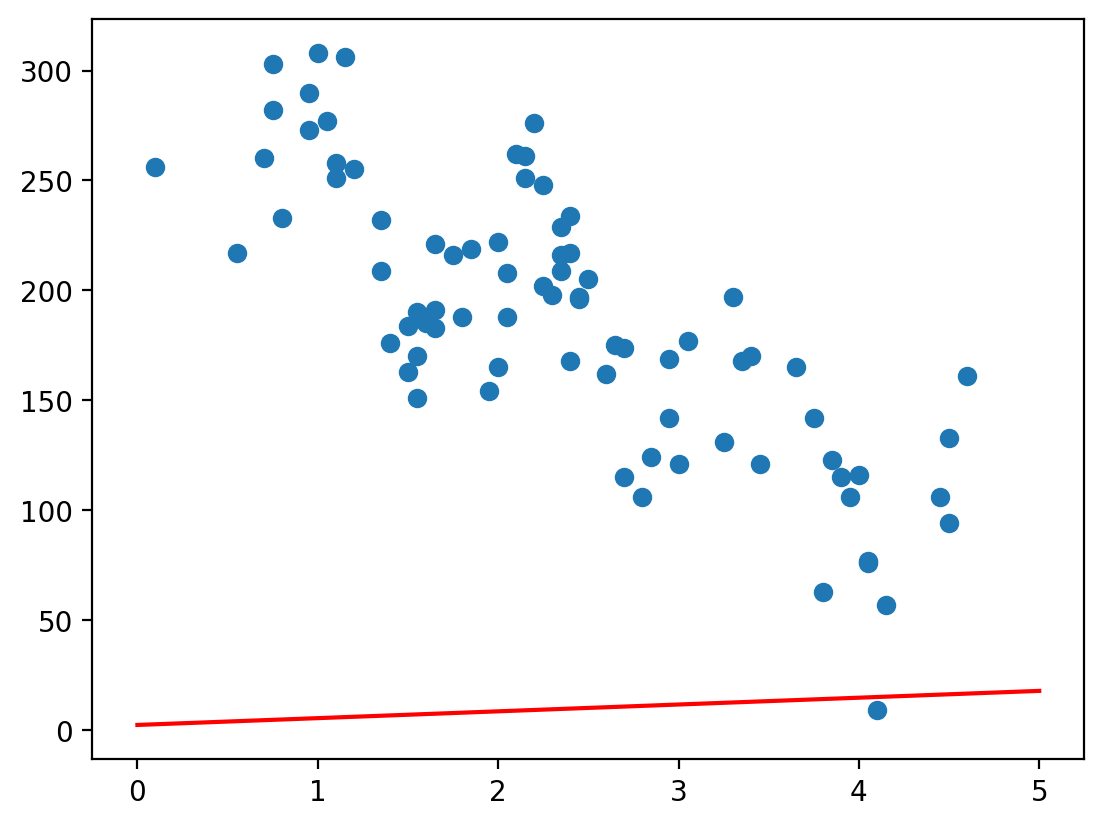

In [15]:
#위의 w와 b값은 아무렇게나 입력해놓은 랜덤한 초깃값입니다. 위와 같은 가중치를 가지는 함수는 다음과 같겠군요.

# y=3.1x×2.3

# 이 그래프를 그려볼까요?
x = np.linspace(0, 5, 6)
y = model(x, w, b) # y = 3.1x + 2.3
plt.plot(y, c='r')

plt.scatter(macbook['used_years'], macbook['price'])
plt.show()

In [16]:
# 음, 아무래도 전혀 맞지 않는 직선이군요. 우리는 더 좋은 

# w와 b를 찾을 필요가 있습니다.

# 그러면 현재의 모델이 얼마나 틀린 답을 만들어내고 있는지를 확인해 봅시다.
# 우리의 데이터 중 used_years를 x를 다시 가져와보겠습니다.
x = macbook["used_years"].values
x

array([2.65, 3.8 , 0.95, 4.5 , 4.45, 2.7 , 3.05, 2.25, 2.3 , 1.85, 1.5 ,
       0.95, 2.6 , 0.55, 2.05, 0.75, 3.95, 2.8 , 2.05, 1.15, 1.35, 3.35,
       1.35, 2.45, 2.4 , 0.1 , 3.45, 2.35, 0.7 , 1.05, 1.75, 4.1 , 4.5 ,
       4.  , 2.  , 2.45, 2.5 , 2.1 , 3.  , 4.05, 2.7 , 2.15, 3.3 , 2.4 ,
       2.85, 1.65, 1.55, 2.15, 3.4 , 1.55, 0.8 , 2.95, 2.4 , 1.4 , 1.65,
       2.25, 3.85, 3.9 , 4.6 , 2.35, 4.05, 1.2 , 1.95, 1.6 , 2.  , 1.8 ,
       3.75, 3.65, 2.35, 2.2 , 1.  , 4.15, 1.1 , 1.55, 2.95, 1.5 , 1.65,
       1.1 , 3.25, 0.75])

In [17]:
# 우리의 모든 데이터에 대한 used_years 값들이 담겼습니다. 
# 이 데이터를 모델에 넣어서 모델이 출력하는 값을 prediction에 담아보죠.
prediction = model(x, w, b) # 현재 w = 3.1, b = 2.3
prediction

array([10.515, 14.08 ,  5.245, 16.25 , 16.095, 10.67 , 11.755,  9.275,
        9.43 ,  8.035,  6.95 ,  5.245, 10.36 ,  4.005,  8.655,  4.625,
       14.545, 10.98 ,  8.655,  5.865,  6.485, 12.685,  6.485,  9.895,
        9.74 ,  2.61 , 12.995,  9.585,  4.47 ,  5.555,  7.725, 15.01 ,
       16.25 , 14.7  ,  8.5  ,  9.895, 10.05 ,  8.81 , 11.6  , 14.855,
       10.67 ,  8.965, 12.53 ,  9.74 , 11.135,  7.415,  7.105,  8.965,
       12.84 ,  7.105,  4.78 , 11.445,  9.74 ,  6.64 ,  7.415,  9.275,
       14.235, 14.39 , 16.56 ,  9.585, 14.855,  6.02 ,  8.345,  7.26 ,
        8.5  ,  7.88 , 13.925, 13.615,  9.585,  9.12 ,  5.4  , 15.165,
        5.71 ,  7.105, 11.445,  6.95 ,  7.415,  5.71 , 12.375,  4.625])

In [18]:
# 각각의 y값에는 x를 입력받은 후 현재의 
# w와 b에 대해 계산해 출력한 값들이 저장되었습니다.

# 그러면 이 값들을 macbook 데이터프레임에 넣어서 실제 값과 얼마나 다른지 확인해 볼 수 있겠습니다.
macbook['prediction'] = prediction
macbook.head()

,used_years,price,prediction
0,2.65,175,10.515
1,3.80,63,14.080
2,0.95,273,5.245
3,4.50,133,16.250
4,4.45,106,16.095


In [ ]:
#prediction이라는 새로운 컬럼에 y 값들을 넣어봤는데, 어떤가요?

#당연히 아직은 실제 정답인 price와 매우 큰 차이가 납니다.
#아직은 조금은 멍청한 모델이기 때문이죠..

# 정답과 예측값 간의 차이

In [19]:
# 우리는 모델에게 "너가 이만큼 틀리고 있어!" 라는 것을 알려줄 것입니다. 
# 그 정보를 바탕으로 모델이 조금씩 개선을 해나갈 수 있는 방법이 있거든요!
# 그렇다면 모델이 얼마나 틀렸는지는 어떻게 평가할 수 있을까요?

# 당연히 "정답과 예측값 간의 차이" 를 생각해 볼 수 있겠습니다.
# 그렇다면 price와 prediction의 차이인 error 컬럼을 새로 만들어보겠습니다.
macbook['error'] = macbook['price'] - macbook['prediction']
macbook.head()

,used_years,price,prediction,error
0,2.65,175,10.515,164.485
1,3.80,63,14.080,48.920
2,0.95,273,5.245,267.755
3,4.50,133,16.250,116.750
4,4.45,106,16.095,89.905


In [20]:
# 에러가 아주 크군요.

# 이 값을 바로 사용해도 되지만, 우리는 특별히 error를 제곱해서 모델의 오차를 측정할 것입니다.
# 제곱을 사용하는 방법 외에도, 에러의 절댓값 등을 사용하는 방법도 있습니다.

# 에러의 종류는 다음 글에서 간단히 살펴보겠습니다.

# 어떤 두 개의 값에 대한 RMSE 값을 구하는 함수는 다음과 같이 간단히 구현할 수 있습니다.
def RMSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    rmse = mse ** 0.5        # MSE의 제곱근
    return rmse
print("슝=3")

슝=3


In [21]:
# 그렇다면 우리의 모델이 출력한 prediction 값과 정답인 y 간에 얼마나 차이가 있는지, RMSE를 구해 보도록 하겠습니다.

# 다시 한 번 모델에 x, w, b를 입력해 predictions를 구해 봅시다.
x = macbook["used_years"].values
y = macbook["price"].values

predictions = model(x, w, b)
print(predictions)

[10.515 14.08   5.245 16.25  16.095 10.67  11.755  9.275  9.43   8.035
  6.95   5.245 10.36   4.005  8.655  4.625 14.545 10.98   8.655  5.865
  6.485 12.685  6.485  9.895  9.74   2.61  12.995  9.585  4.47   5.555
  7.725 15.01  16.25  14.7    8.5    9.895 10.05   8.81  11.6   14.855
 10.67   8.965 12.53   9.74  11.135  7.415  7.105  8.965 12.84   7.105
  4.78  11.445  9.74   6.64   7.415  9.275 14.235 14.39  16.56   9.585
 14.855  6.02   8.345  7.26   8.5    7.88  13.925 13.615  9.585  9.12
  5.4   15.165  5.71   7.105 11.445  6.95   7.415  5.71  12.375  4.625]


In [22]:
# 그 후 RMSE() 함수에 predictions 와 y를 넣으면 둘 간의 rmse값을 구할 수 있습니다.
rmse = RMSE(predictions, y)
rmse

np.float64(188.81322969819274)

In [23]:
# 단위가 만원단위인걸 생각해보면 오차가 너무 큼. 맥북가격이 100~200정도하는데 거의 기기가격만큼 오차가 발생함.

# 손실함수(비용함수)

In [24]:
#즉, 손실값(loss)이 크다는 것은 모델이 현재 정답과 굉장히 먼 예측을 하고 있다는 뜻이고, 
#손실값이 작다는 것은 모델이 정답에 가까운, 올바른 예측을 하고 있다는 것으로 해석할 수 있습니다. 
#따라서 손실값은 작을수록 좋습니다.

# 그러면 우리의 손실함수를 RMSE를 활용해 다음과 같이 정의하도록 하겠습니다.
def loss(x, w, b, y):
    predictions = model(x, w, b)
    L = RMSE(predictions, y)
    return L

In [ ]:
#손실함수와 비용함수 또한 머신 러닝 모델의 학습 과정에서 굉장히 중요한 개념이므로 꼭 
#그 정확한 개념을 기억하고 있는 것이 좋습니다!

#그렇다면 이제 rmse값, 즉 우리 모델의 손실함수값을 줄여나가야겠죠.

# 8-5 모델을 점점 똑똑하게 만드는 방법

In [ ]:
# 기울기와 경사하강법 (Gradient Descent)
#그런데 이 값을 어떻게 줄여나갈까요?

#최적의 w가 어디에 있고, 현재 내 위치가 최적의 w보다 오른쪽인지, 왼쪽인지 알지 못하더라도
#현재 내 위치에서의 기울기만 알 수 있다면 내 위치를 어느 방향으로 옮겨야 하는지를 알 수 있게 되는 것이죠.

#따라서 우리는 기울기를 활용해서 다음과 같은 규칙으로 w를 업데이트 하면 됩니다!

#현재 w에서의 기울기를 구한다.
#기울기가 음수라면, 현재 w를 키운다.
#기울기가 양수라면, 현재 w를 줄인다.
#이러한 규칙을 깔끔하게 수식으로 나타내면 다음과 같습니다.

#w`=w−ηg

#w'  : 새로운 w
#w : 현재 w
#η : 얼마나 업데이트를 할 지를 결정하는 상수 (학습률)
#g : 기울기, 또는 그래디언트

#이렇게 기울기를 사용해서 점차적으로 매개변수를 업데이트 하는 방식을 Gradient Descent Method, 
#즉 경사하강법 이라고 합니다.

# 미분으로 경사 구하기

In [26]:
# 실제로는 극한을 사용해서 Δx가 0에 무한히 가까워져야 하지만, 값을 구하는 데에는 충분히 작은 값이라면 충분하기 때문에 우리는 
# Δx를 0.0001로 두고 계산하겠습니다.

# 이렇게 수학적으로 정확한 값은 아니지만 근사한 미분계수 값을 찾는 방법을 수치미분 이라고 합니다.

# forward Difference 전방차분
def gradient(x, w, b, y):
    dw = (loss(x, w + 0.0001, b, y) - loss(x, w, b, y)) / 0.0001
    db = (loss(x, w, b + 0.0001, y) - loss(x, w, b, y)) / 0.0001
    return dw, db

# Centered Difference중앙차분
def gradient_center(x, w, b, y):
    h = 0.0001
    # (w + h)와 (w - h) 사이의 차이를 구한 뒤 2h로 나눕니다.
    dw = (loss(x, w + h, b, y) - loss(x, w - h, b, y)) / (2 * h)
    db = (loss(x, w, b + h, y) - loss(x, w, b - h, y)) / (2 * h)
    return dw, db

# 8-6. 한 번에 못해도 괜찮아, 정의된 손실함수와 기울기 함수로 모델을 학습시켜 최적화하기!

In [ ]:
# 자, 이제 손실함수와 기울기가 모두 준비되었으니 우리는 단계별로 최적의 w와 b에 접근하며 최적의 모델, 
# wx+b를 찾아내기만 하면 되겠군요.

# 바로 코드로 구현해 보겠습니다. 구현은 지금까지 배웠던 이론보다도 어렵지 않습니다!

# 하이퍼 파라미터
# 먼저 경사하강법에서 필요했던 학습률, 
# η 상수를 정의하고 시작하겠습니다.

In [27]:
LEARNING_RATE = 0.01
print("슝=3")

슝=3


In [ ]:
# 사실 학습률은 1이 아니어도 됩니다.
# 어떤 학습률을 사용하는 것이 가장 좋은지는 실제로 실험을 해 보기 전까지는 모릅니다.

# 이렇게 학습률과 같이 모델이 스스로 학습해나가는 파라미터 가 아니라, 
# 사람이 직접 사전에 정하고 시작해야 하는 파라미터 를 하이퍼 파라미터 라고 합니다.

# 이제는 다음 순서대로 코드를 구현하기만 하면 됩니다!

# 1 입력 데이터 x와 정답 데이터 y 준비
# 2 초기 w, b를 랜덤하게 선택
# 3 현재의 w와 b로 모델이 prediction을 예측하고, 그 값과 y 값을 비교해서 손실함수값 계산
# 4 손실함수값을 계산함과 동시에 그 점에서의 기울기, gradient 계산
# 5 계산된 gradient를 활용해서 w`=w−ηg, b`=b−ηg 로 업데이트
# 6. 3~5 번의 과정을 손실함수가 충분히 줄어들 때까지 반복

In [29]:
# 모델 최적화

# 그러면 이 순서대로 시작하겠습니다! 일부 과정은 이미 해봤지만, 복습하기 위해 다시 한 번 실행해 보겠습니다.
# 먼저 가장 중요한, 우리의 데이터 x와 y를 준비합니다.
x = macbook["used_years"].values
y = macbook["price"].values
print("슝=3")


슝=3


In [57]:
#초기 가중치들을 랜덤한 값으로 설정하고 시작합니다.

w = 3.1
b = 2.3
w, b

# 손실함수값이 단계별로 얼마 정도인지를 저장할 losses라는 빈 리스트를 준비해 보겠습니다.
# 학습에 영향을 주는 부분은 아니지만, 
# 실험이 매우 중요한 머신러닝 분야에서 학습이 어떤 식으로 진행되는지를 확인하는 습관을 갖는 것은 중요합니다.



(3.1, 2.3)

In [58]:
#그러면 이제 대망의 학습 단계입니다! 위에서 3~5번의 과정을 반복한다고 했습니다.
# 몇 번 정도 반복하는 것이 좋을까요?

# 자, 그러면 다음 과정을 파이썬의 for 구문으로 반복해서 학습을 진행해 보도록 하겠습니다!
LEARNING_RATE = 0.1
losses = []
losses.clear()

In [59]:
%%time
for i in range(1, 20001):
    dw, db = gradient(x, w, b, y)   # 3, 4번: 모델이 prediction을 예측하고, 손실함수값을 계산함과 동시에 기울기 계산
    w -= LEARNING_RATE * dw         # 5번: w = w - η * dw 로 업데이트
    b -= LEARNING_RATE * db         # 5번: b = b - η * db 로 업데이트
    L = loss(x, w, b, y)            # 현재의 loss 값 계산
    losses.append(L)                # loss 값 기록
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 151.2695
Iteration 200 : Loss 130.2740
Iteration 300 : Loss 121.1318
Iteration 400 : Loss 117.2757
Iteration 500 : Loss 115.1762
Iteration 600 : Loss 113.5913
Iteration 700 : Loss 112.1516
Iteration 800 : Loss 110.7544
Iteration 900 : Loss 109.3718
Iteration 1000 : Loss 107.9967
Iteration 1100 : Loss 106.6272
Iteration 1200 : Loss 105.2631
Iteration 1300 : Loss 103.9045
Iteration 1400 : Loss 102.5513
Iteration 1500 : Loss 101.2040
Iteration 1600 : Loss 99.8626
Iteration 1700 : Loss 98.5275
Iteration 1800 : Loss 97.1987
Iteration 1900 : Loss 95.8766
Iteration 2000 : Loss 94.5613
Iteration 2100 : Loss 93.2532
Iteration 2200 : Loss 91.9526
Iteration 2300 : Loss 90.6596
Iteration 2400 : Loss 89.3745
Iteration 2500 : Loss 88.0977
Iteration 2600 : Loss 86.8295
Iteration 2700 : Loss 85.5702
Iteration 2800 : Loss 84.3201
Iteration 2900 : Loss 83.0796
Iteration 3000 : Loss 81.8490
Iteration 3100 : Loss 80.6287
Iteration 3200 : Loss 79.4190
Iteration 3300 : Loss 78.2204
Iter

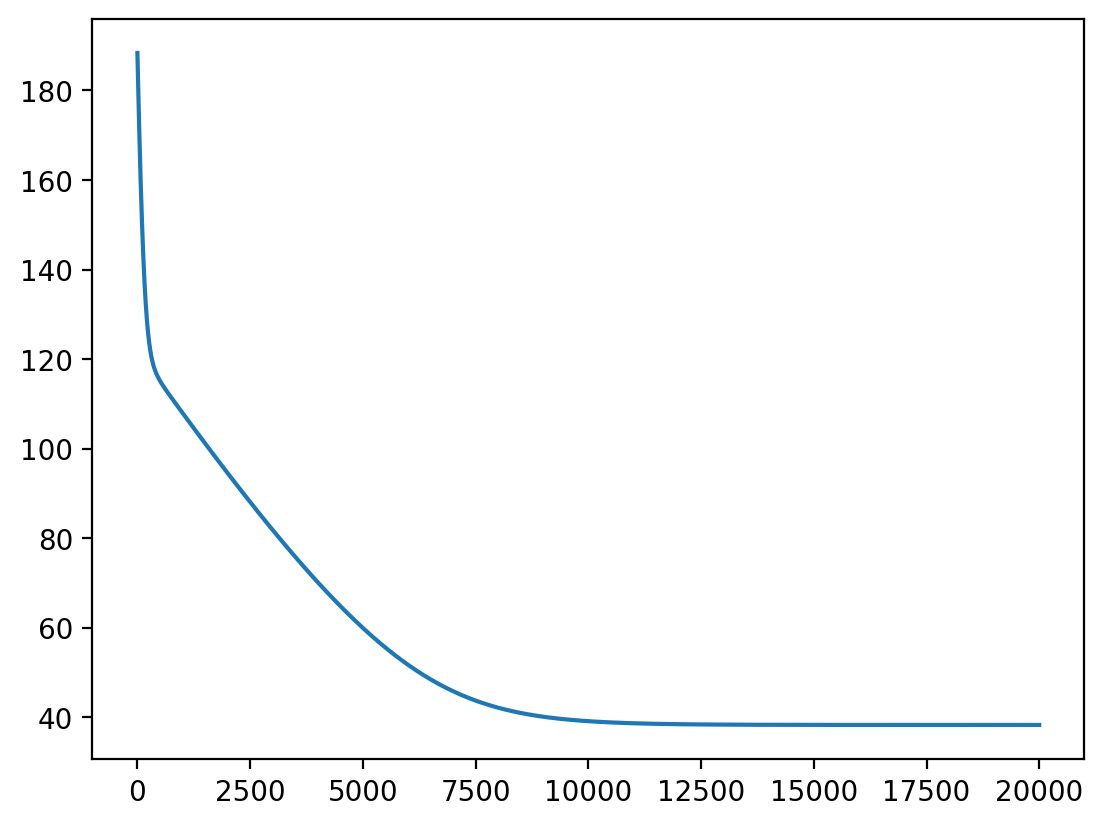

In [60]:
# 오호, 학습을 반복해나가면서 loss 값이 효과적으로 떨어지고 있는 것이 보이는군요!

# 모든 loss 값을 losses 리스트에 저장해 두었으니 그래프로 한번 확인해 봅시다.
plt.plot(losses)
plt.show()

In [61]:
# 초기 180 이상으로 매우 컸던 loss 값이 40 이하로 잘 떨어진 것을 확인할 수 있습니다.

# 특히, 1,000단계 이후로는 거의 떨어지지 않는군요. 거의 최적에 도달했기 때문에 아무리 업데이트를 해도 더 이상 떨어지지 않는 단계에 다다른 것으로 보입니다.

# 그렇다면 지금의 w와 b 값을 한번 확인해 볼까요?
w, b

(np.float64(-44.92642054726647), np.float64(293.0783789179064))

In [62]:
# 적당한 값들로 수렴한 것 같군요.

# 그러면 이제 원래 우리의 데이터와 학습이 완료된 모델, 일차함수를 함께 그려보겠습니다.

w = -44.92642054726647
b = 293.0783789179064

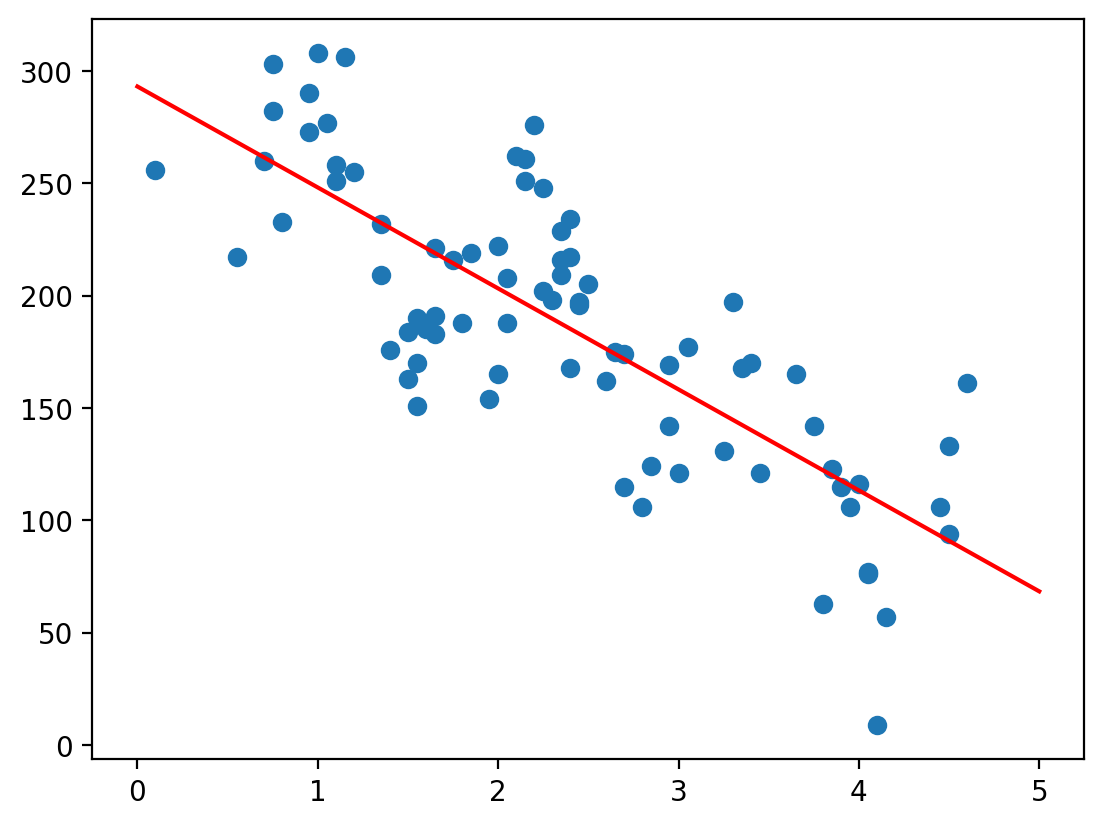

In [63]:
# 모델에 넣을 x 값들 준비
x = np.linspace(0, 5, 6)

# x, w, b를 모델에 넣어 y값 출력
y = model(x, w, b)

# 일차함수 y 그리기
plt.plot(y, c="r")


# 원본 데이터 점찍기
plt.scatter(macbook['used_years'], macbook['price'])
plt.show()

In [65]:
#아래 코드로 새로운 데이터인 macbook_test 데이터를 가져와 보겠습니다.
test_path = os.path.join(os.getenv('HOME'), 
'work/AIFFEL_study/DA_macbook_bike/data/macbook_test.csv')
test = pd.read_csv(test_path)
print(test.shape)
test.head()

(20, 2)


,used_years,price
0,1.20,203
1,1.85,206
2,2.40,191
3,2.85,164
4,3.05,176


In [66]:
#위 데이터는 학습했던 데이터와 같은 경향성을 가지지만, 모델이 학습하는 과정에서는 접해 보지 않은(unseen) 데이터입니다.
#크기는 20개로 크지 않은 간단한 데이터이군요.

# 예상 가능하지만, 위 데이터에 대해서도 모델은 잘 맞출 수 있겠죠?

# test 데이터를 새로 test_x와 test_y에 담아보겠습니다.
test_x = test['used_years'].values
test_y = test['price'].values

In [67]:
# 이제 모델에게 새로운 test_x 데이터를 넣어서 test_prediction을 구해 보죠!
prediction = model(test_x, w, b)
test['prediction'] = prediction
test

,used_years,price,prediction
0,1.20,203,239.166674
1,1.85,206,209.964501
2,2.40,191,185.254970
3,2.85,164,165.038080
4,3.05,176,156.052796
5,3.35,136,142.574870
6,2.55,133,178.516007
7,2.60,181,176.269685
8,2.50,181,180.762328
9,3.10,86,153.806475


In [68]:
# 오호, 언뜻 봤을 때 실제 가격과 비슷한 예측을 해내는 것 같습니다.

# error를 직접 계산해서 새로운 컬럼으로 넣어보죠.
test['error'] = test['price'] - test['prediction']
test

,used_years,price,prediction,error
0,1.20,203,239.166674,-36.166674
1,1.85,206,209.964501,-3.964501
2,2.40,191,185.254970,5.745030
3,2.85,164,165.038080,-1.038080
4,3.05,176,156.052796,19.947204
5,3.35,136,142.574870,-6.574870
6,2.55,133,178.516007,-45.516007
7,2.60,181,176.269685,4.730315
8,2.50,181,180.762328,0.237672
9,3.10,86,153.806475,-67.806475


In [69]:
# 이쯤 했다면 위에서 우리가 손실함수로 사용했던 rmse 값도 직접 구해 볼 수 있겠네요!
rmse = ((test['error'] ** 2).sum() / len(test)) ** 0.5
rmse

np.float64(45.0389424497311)

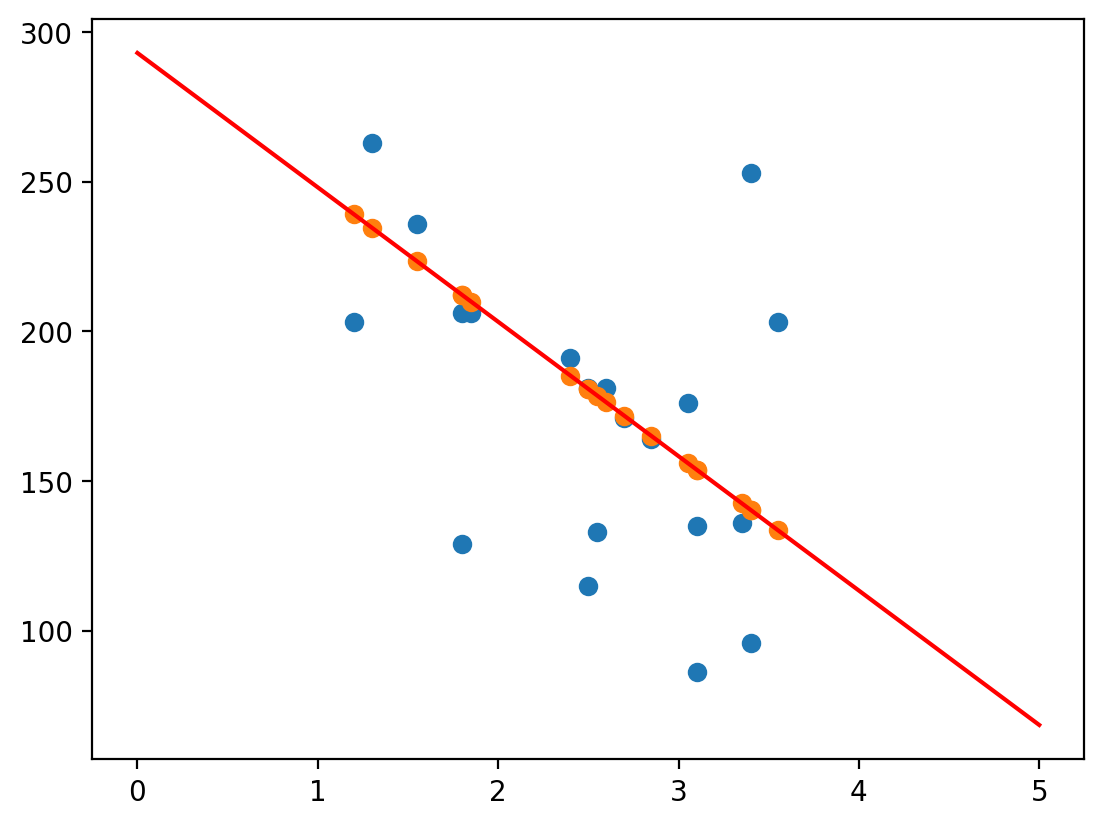

In [70]:
# 모델 일차함수 그리기
x = np.linspace(0, 5, 6)
y = model(x, w, b)
plt.plot(y, c="r")

# 실제 데이터 값
plt.scatter(test['used_years'], test['price'])

# 모델이 예측한 값
plt.scatter(test['used_years'], test['prediction'])
plt.show()

# 8-7. 손님의 성별,수, 전체 먹은 금액 등으로 내가 받은 팁을 예측할 수 있을까?

In [ ]:
# 자, 우리는 이전 단계에서 단 하나의 정보인 "사용 연수"만을 
# 가지고 맥북의 중고가를 예측해 보는 일차함수 모델을 설계하고 학습도 시켜보았습니다.

# 손님의 성별, 수, 전체 먹은 금액 등으로 내가 받을 팁을 예측할 수 있을까?

# 다변수 데이터에 대해 선형회귀를 하기 위한 데이터를 확인하고 모델 설계하기


#자, 이번에 사용할 데이터에는 단 하나의 정보만이 담겨있지 않습니다. 여러 가지 변수로 하나의 값이 결정되죠.

#우리는 이번에 손님 테이블에 대한 여러 가지 정보가 담긴 데이터셋으로 그 테이블이 낼 팁(tip)을 예측해 볼 것입니다.
#어떤 정보가 있고, 그 정보를 활용해서 효과적으로 팁을 예측할 수 있을지 실험해 보죠.

#팁 데이터셋은 데이터 시각화 패키지인 seaborn 패키지 안에 포함되어 있습니다.